# Activation Functions and Optimization Algorithms

## 📚 Learning Objectives

By completing this notebook (~20 min), you will:
- Plot and compare common activation functions (ReLU, sigmoid, tanh)
- Understand why we use ReLU in hidden layers instead of sigmoid
- See how optimizers (SGD vs Adam) affect training on a tiny example

## 🔗 Where this fits

**Builds on:** Course 01 (AIAT 111) — Unit 4, lesson 03 "Single Neuron with Different Activation Functions" — you plotted sigmoid, tanh and ReLU there; here you see which one actually trains.

---

## 🌍 Real life

**📌 Real case — the activation that made AlexNet possible.** Krizhevsky, Sutskever and Hinton (NeurIPS 2012) report in their Figure 1 that a four-layer CNN with **ReLU** units reached 25% training error on CIFAR-10 **six times faster** than the identical network with tanh units. They are blunt about the consequence: "we would not have been able to experiment with such large neural networks for this work if we had used traditional saturating neuron models." That same network won ILSVRC-2012 with a **15.3% top-5 error against 26.2% for the second-best entry** — the result that started the modern deep-learning era. The difference was, in large part, the choice you are about to plot.

**⚡ Why this matters — what goes wrong without it.** Sigmoid and tanh flatten out at both ends. Where the curve is flat the derivative is nearly zero, and backpropagation multiplies those near-zero numbers layer by layer, so by the time the gradient reaches the early layers there is nothing left to update. The failure is silent: no error, no crash — the loss simply stops moving and you cannot see why. The optimizer half of this notebook shows the same silence with numbers: same model, same data, same 3 epochs, and SGD finishes at loss **1.7581** while Adam finishes at **0.4905**.

**Where is this used?** Activation functions appear in **every layer** of neural networks (speech, vision, NLP). Optimizers (SGD, Adam) are used in **all deep learning training** in industry and research.

**In this notebook we use** **activation functions** to introduce **non-linearity** so the network can learn complex patterns. We use **ReLU** in hidden layers (instead of sigmoid) **because** ReLU avoids vanishing gradients and trains faster. We compare **SGD and Adam** so you see how the choice of optimizer affects convergence.

**📌 Covers slide(s):** **19** — Perceptron, MLP, activation functions (revisit). *Do this notebook after that slide.*

---

**Before starting:** Run the imports cell below.


## Theory (short)

- **Activation function:** Applied after each layer (except sometimes the output). Without it, stacking layers would be equivalent to one linear layer.
- **ReLU:** max(0, x). Fast, avoids vanishing gradient in positive part; used in most hidden layers.
- **Sigmoid / tanh:** Saturate for large |x|, so gradients can vanish; used in outputs (e.g. sigmoid for binary) or in gates (LSTM).
- **Optimizer:** Updates weights using gradients. **SGD:** one learning rate for all. **Adam:** per-parameter adaptive rates; usually converges faster in practice.
- **We use ReLU in hidden layers** instead of sigmoid because ReLU trains faster and avoids vanishing gradients.

### Key math (required)

- **ReLU:** \(\text{ReLU}(x) = \max(0, x)\); derivative: \(1\) if \(x>0\), \(0\) if \(x\le 0\).
- **Sigmoid:** \(\sigma(x) = \frac{1}{1+e^{-x}}\); derivative \(\sigma'(x) = \sigma(x)(1-\sigma(x))\).
- **Tanh:** \(\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}\); derivative \(1 - \tanh^2(x)\).
- **SGD update:** \(w \leftarrow w - \eta\,\nabla_w L\). **Adam** uses adaptive estimates of first and second moments of gradients; see slides or reference for the full formula.

**The steps below put this theory into code.**

💡 **If this is unclear:** First run the **activation plots** (ReLU, sigmoid, tanh) — they show why we use ReLU in hidden layers. Then run the **optimizer comparison** (SGD vs Adam). One sentence: ReLU avoids vanishing gradients; Adam adapts the learning rate per parameter. If stuck, tell your instructor: "I didn't get the activation or optimizer part in notebook 04."


## 📥 Inputs & 📤 Outputs

**Inputs:** NumPy, Matplotlib, TensorFlow (optional). We use a small grid of values to plot activations and a tiny MNIST subset to compare optimizers.

**Dataset:** Real — MNIST (small subset for SGD vs Adam comparison).

**Outputs:** One figure with the activation curves (ReLU, sigmoid, tanh) **and their derivatives**, plus the arithmetic of the vanishing gradient printed underneath; then an SGD vs Adam comparison over 10 epochs from identical starting weights, in both loss and accuracy.

## Step 1: Imports

In [1]:
# WHAT: import NumPy/Matplotlib and try TensorFlow, with a clear fix if the install is broken.
# WHY: the activation plots are pure math (NumPy), but the optimizer demo later needs TensorFlow.
import numpy as np
import matplotlib.pyplot as plt

# Guarded import: catch a broken TensorFlow install and print the exact repair command instead of a confusing crash.
try:
    import tensorflow as tf
    HAS_TF = True
except Exception as e:
    err = str(e).lower()
    if "charset_normalizer" in err or "md__mypyc" in err or "partially initialized" in err:
        print("⚠️ Fix: pip install --upgrade charset-normalizer requests, then restart kernel.")
        raise RuntimeError("Fix: pip install --upgrade charset-normalizer requests, then restart kernel.") from e
    HAS_TF = False

print("NumPy, Matplotlib ready.", "TensorFlow:", "yes" if HAS_TF else "no")

NumPy, Matplotlib ready. TensorFlow: yes


## Step 2: Define and plot activation functions (we use ReLU in hidden layers instead of sigmoid to avoid vanishing gradients)

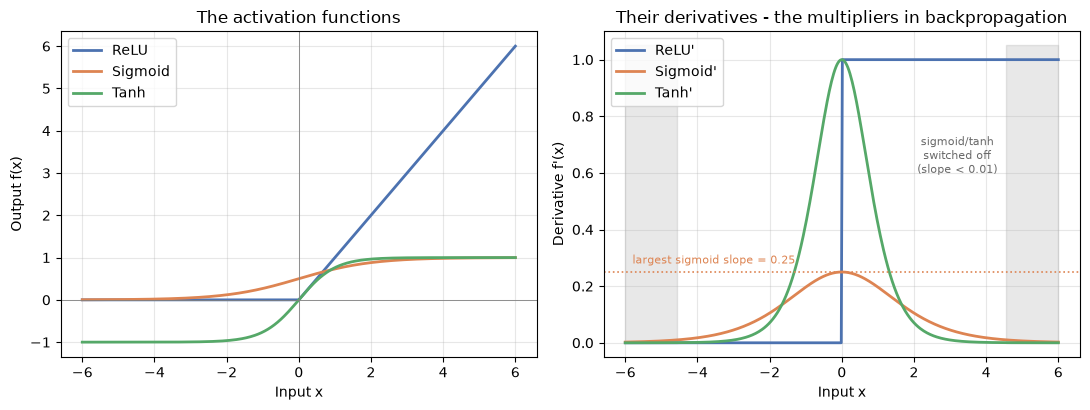

Largest sigmoid derivative anywhere:  0.2500
Largest tanh derivative anywhere:     0.9998
ReLU derivative for x > 0:            1.0000
Share of the plotted range where the sigmoid slope is below 0.01: 24%

Backpropagation multiplies one derivative per layer. Best case through 5 layers:
  5 sigmoid layers: 0.25^5 = 0.000977   (the gradient arrives ~1024x smaller)
  5 ReLU layers   : 1.00^5 = 1.000000   (the gradient arrives unchanged)


In [2]:
# WHAT: plot ReLU, Sigmoid and Tanh AND their derivatives on the same input range.
# WHY: the left panel shows the shapes; the right panel is where the lesson actually lives.
#      Backpropagation multiplies one derivative per layer, so a derivative near zero
#      switches learning off for every layer beneath it. You cannot see that in the left panel.
x = np.linspace(-6, 6, 400)
relu = np.maximum(0, x)
sigmoid = 1 / (1 + np.exp(-x))
tanh = np.tanh(x)

# Derivatives (the numbers backpropagation actually multiplies together)
d_relu = (x > 0).astype(float)
d_sigmoid = sigmoid * (1 - sigmoid)
d_tanh = 1 - tanh ** 2

fig, (axL, axR) = plt.subplots(1, 2, figsize=(11, 4.2))

# --- Left: the functions themselves -----------------------------------------
for y, name, c in [(relu, "ReLU", "#4c72b0"), (sigmoid, "Sigmoid", "#dd8452"), (tanh, "Tanh", "#55a868")]:
    axL.plot(x, y, label=name, linewidth=2, color=c)
axL.axhline(0, color="grey", lw=0.6); axL.axvline(0, color="grey", lw=0.6)
axL.set_xlabel("Input x"); axL.set_ylabel("Output f(x)")
axL.set_title("The activation functions")
axL.legend(); axL.grid(True, alpha=0.3)

# --- Right: their derivatives, which is what decides whether learning happens -
for y, name, c in [(d_relu, "ReLU'", "#4c72b0"), (d_sigmoid, "Sigmoid'", "#dd8452"), (d_tanh, "Tanh'", "#55a868")]:
    axR.plot(x, y, label=name, linewidth=2, color=c)
# Shade where sigmoid and tanh have essentially switched off (derivative below 0.01).
sat = np.abs(x) >= x[d_sigmoid >= 0.01].max()
axR.fill_between(x, 0, 1.05, where=sat, color="grey", alpha=0.18)
axR.axhline(0.25, color="#dd8452", ls=":", lw=1.2)
axR.text(-5.8, 0.28, "largest sigmoid slope = 0.25", fontsize=8, color="#dd8452")
axR.text(3.2, 0.60, "sigmoid/tanh\nswitched off\n(slope < 0.01)", fontsize=8, color="dimgrey", ha="center")
axR.set_xlabel("Input x"); axR.set_ylabel("Derivative f'(x)")
axR.set_ylim(-0.05, 1.10)
axR.set_title("Their derivatives - the multipliers in backpropagation")
axR.legend(loc="upper left"); axR.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# The vanishing gradient as arithmetic, not adjectives.
print(f"Largest sigmoid derivative anywhere:  {d_sigmoid.max():.4f}")
print(f"Largest tanh derivative anywhere:     {d_tanh.max():.4f}")
print(f"ReLU derivative for x > 0:            1.0000")
frac = float(np.mean(d_sigmoid < 0.01))
print(f"Share of the plotted range where the sigmoid slope is below 0.01: {100*frac:.0f}%")
print()
print("Backpropagation multiplies one derivative per layer. Best case through 5 layers:")
print(f"  5 sigmoid layers: 0.25^5 = {0.25**5:.6f}   (the gradient arrives ~{1/0.25**5:.0f}x smaller)")
print(f"  5 ReLU layers   : 1.00^5 = {1.0**5:.6f}   (the gradient arrives unchanged)")


**Read the figure.**

- **Left panel** — the shapes. ReLU is a straight line above zero and flat below it; sigmoid and tanh flatten at *both* ends. Nothing here tells you which one to use.
- **Right panel** — the same inputs, but now the **derivatives**, and this is the panel that decides. Backpropagation multiplies one derivative per layer on the way back, so a derivative near zero silences every layer beneath it. Sigmoid's derivative never exceeds the dotted line at **0.25** (its peak, at x = 0). Tanh reaches ~1.0, but only in a narrow band around zero. ReLU's is exactly **1** for every positive input. The grey bands mark where the sigmoid slope has fallen below 0.01 — **24%** of the plotted range, and tanh is far below 0.01 there as well.
- **The arithmetic underneath is the actual lesson.** Five stacked sigmoid layers multiply the returning gradient by at most 0.25⁵ = 0.000977: it arrives about **1,024× smaller** than it left, in the *best* case. Five ReLU layers on their positive side multiply it by 1 and change nothing.

**What it proves:** "ReLU avoids vanishing gradients" is not a slogan; it is 1⁵ against 0.25⁵. **What it does not prove:** that ReLU is free. Look at the blue line on the left half of the right panel — it is exactly 0. A unit driven permanently negative receives no gradient at all and never recovers; that failure has a name, *dying ReLU*, and it is why Leaky ReLU and GELU exist.

## Step 3: Compare SGD vs Adam on a tiny MNIST subset (we use Adam when we want faster convergence)

/Users/abdullah/venvs/ai-diploma-tf/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


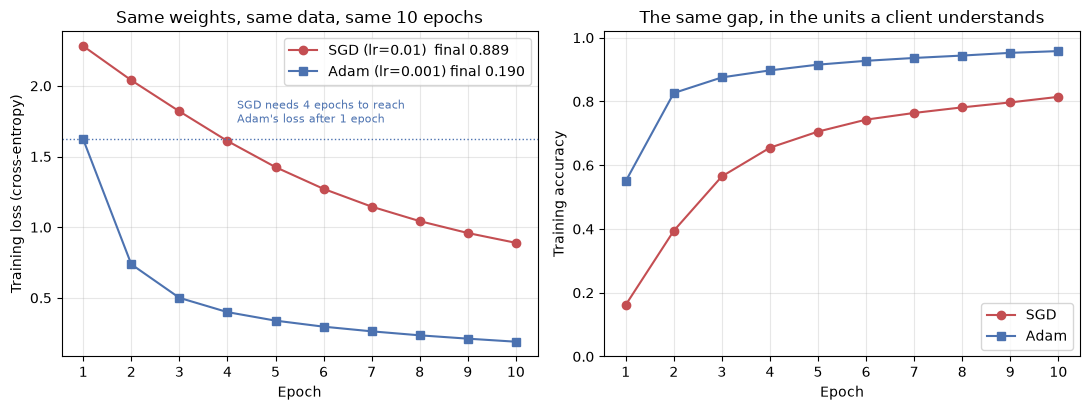

Loss after 1 epoch   SGD 2.2811   Adam 1.6208
Loss after 10 epochs SGD 0.8895   Adam 0.1898
Accuracy after 10 epochs  SGD 0.8145   Adam 0.9580


In [3]:
# WHAT: train the SAME network twice on 2,000 MNIST digits, changing only the optimizer.
# WHY: with identical starting weights and identical data, every difference in the curves
#      below is caused by the update rule and nothing else.
if not HAS_TF:
    print("Skipping optimizer comparison (TensorFlow not available). Install: pip install tensorflow")
else:
    # A small MNIST subset keeps each training run to a few seconds.
    (x_train, y_train), _ = tf.keras.datasets.mnist.load_data()
    x_train = x_train.astype(np.float32) / 255.0
    x_train = x_train.reshape(-1, 784)[:2000]
    y_train = y_train[:2000]

    # Re-seeding before each build gives BOTH runs exactly the same initial weights,
    # so the comparison is about the optimizer, not about a lucky initialisation.
    def build_model():
        tf.keras.utils.set_random_seed(0)
        return tf.keras.Sequential([
            tf.keras.layers.Dense(64, activation="relu", input_shape=(784,)),
            tf.keras.layers.Dense(10, activation="softmax"),
        ])

    EPOCHS = 10   # 10 epochs x 32 mini-batches on 2,000 images: still only a few seconds

    model_sgd = build_model()
    model_sgd.compile(optimizer="sgd", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    hist_sgd = model_sgd.fit(x_train, y_train, epochs=EPOCHS, batch_size=64, verbose=0, shuffle=False)

    model_adam = build_model()
    model_adam.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    hist_adam = model_adam.fit(x_train, y_train, epochs=EPOCHS, batch_size=64, verbose=0, shuffle=False)

    ls, la = hist_sgd.history["loss"], hist_adam.history["loss"]
    ep = np.arange(1, EPOCHS + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))
    # Left: loss per epoch for both optimizers, from the identical starting point.
    ax1.plot(ep, ls, "o-", color="#c44e52", label=f"SGD (lr=0.01)  final {ls[-1]:.3f}")
    ax1.plot(ep, la, "s-", color="#4c72b0", label=f"Adam (lr=0.001) final {la[-1]:.3f}")
    # Mark how long SGD needs to reach the loss Adam already had after one epoch.
    reached = np.where(np.array(ls) <= la[0])[0]
    ax1.axhline(la[0], color="#4c72b0", ls=":", lw=1)
    note = (f"SGD needs {reached[0] + 1} epochs to reach\nAdam's loss after 1 epoch"
            if len(reached) else f"SGD never reaches Adam's\nepoch-1 loss ({la[0]:.3f}) in {EPOCHS} epochs")
    ax1.text(EPOCHS * 0.42, la[0] + 0.12, note, fontsize=8, color="#4c72b0")
    ax1.set_xlabel("Epoch"); ax1.set_ylabel("Training loss (cross-entropy)")
    ax1.set_title("Same weights, same data, same 10 epochs")
    ax1.set_xticks(ep); ax1.legend(); ax1.grid(alpha=0.3)

    # Right: the same two runs measured as accuracy, which is what a client asks about.
    ax2.plot(ep, hist_sgd.history["accuracy"], "o-", color="#c44e52", label="SGD")
    ax2.plot(ep, hist_adam.history["accuracy"], "s-", color="#4c72b0", label="Adam")
    ax2.set_xlabel("Epoch"); ax2.set_ylabel("Training accuracy")
    ax2.set_ylim(0, 1.02); ax2.set_xticks(ep)
    ax2.set_title("The same gap, in the units a client understands")
    ax2.legend(loc="lower right"); ax2.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

    print(f"Loss after 1 epoch   SGD {ls[0]:.4f}   Adam {la[0]:.4f}")
    print(f"Loss after {EPOCHS} epochs SGD {ls[-1]:.4f}   Adam {la[-1]:.4f}")
    print(f"Accuracy after {EPOCHS} epochs  SGD {hist_sgd.history['accuracy'][-1]:.4f}   "
          f"Adam {hist_adam.history['accuracy'][-1]:.4f}")


**Read the figure.**

- **Left** — the same network, the same 2,000 images, the same 10 epochs. Re-seeding before each build means both runs start from *identical* weights, so every gap between the curves is caused by the update rule alone. Adam is below SGD at every single epoch. The dotted line is the loss Adam had already reached after **one** epoch (1.62); SGD takes **4** epochs to arrive there, and after 10 epochs it is still at 0.889 against Adam's 0.190.
- **Right** — the same two runs in accuracy, because that is the number a client will ask for: **0.815 for SGD, 0.958 for Adam** after 10 epochs.

**What it proves:** on this task, at each optimizer's default learning rate, Adam converges much faster per epoch. **What it does not prove:** that SGD is a bad optimizer. Both defaults were used as-is (SGD lr = 0.01, Adam lr = 0.001), and a tuned learning rate — or a schedule with momentum — closes most of this gap; large image models are still trained with SGD + momentum. That is Discuss question 1, and it is worth arguing before you accept the picture.

*(A second optimizer comparison appears further down in the worked example. It is deliberately a different setup — 8×8 sklearn digits instead of MNIST, full-batch instead of mini-batch, 150 steps instead of 10 epochs, and a third optimizer, RMSprop — so that you can see the effect is not an artefact of one dataset.)*

## 🌍 Real-World Worked Example — Comparing Optimizers on Image Classification

**Industry context — quoted from the papers, not from memory.** The GPT-3 paper states "we use Adam with β1 = 0.9, β2 = 0.95" (Brown et al., 2020, [arXiv:2005.14165](https://arxiv.org/abs/2005.14165)). The T5 paper states "For optimization, we use AdaFactor" (Raffel et al., JMLR 2020, [arXiv:1910.10683](https://arxiv.org/abs/1910.10683)). Two of the most-copied training recipes in the field, two different optimizers — which is exactly why the comparison below is worth running yourself.

We compare SGD, RMSprop, and Adam on the **Digits** dataset to see the difference.

SGD (lr=0.01)        → final acc: 78.1%
RMSprop              → final acc: 97.2%
Adam                 → final acc: 96.9%


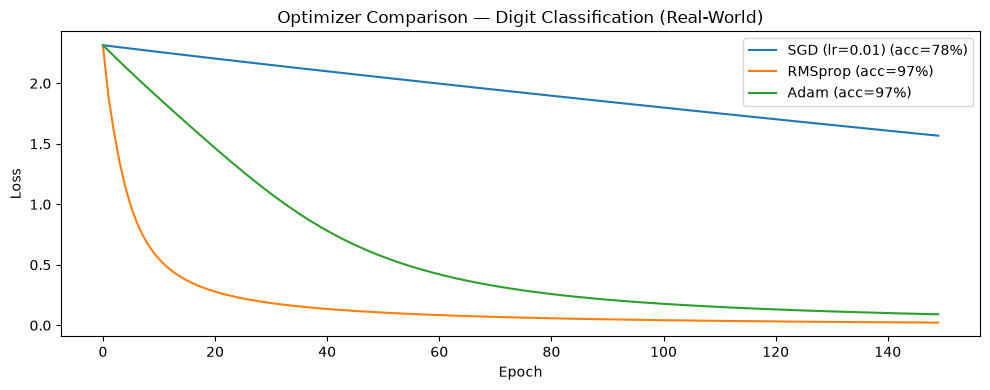

In [4]:
# WHAT: train the same small network three times, changing only the optimizer (SGD, RMSprop, Adam).
# WHY: with data, model and epochs held fixed, any difference in the loss curves comes from the update rule alone.
import torch, torch.nn as nn
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np, matplotlib.pyplot as plt

# Load the 8x8 digits dataset and standardize features so all optimizers start from comparable conditions.
digits = load_digits()
X = StandardScaler().fit_transform(digits.data.astype(np.float32))
y = digits.target
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)
Xtr = torch.tensor(X_tr); Ytr = torch.tensor(y_tr, dtype=torch.long)
Xte = torch.tensor(X_te); Yte = torch.tensor(y_te, dtype=torch.long)

# A fresh model per optimizer - reusing weights would contaminate the comparison.
# The seed is reset inside make_model() so all three optimizers start from the SAME weights
# and the printed accuracies are the same every run (the text below quotes them).
def make_model():
    torch.manual_seed(0)
    return nn.Sequential(nn.Linear(64,128), nn.ReLU(), nn.Linear(128,10))

# The three contenders: plain SGD, RMSprop (adaptive step per weight), Adam (adaptive step + momentum).
optimizers = {
    'SGD (lr=0.01)':   lambda m: torch.optim.SGD(m.parameters(), lr=0.01),
    'RMSprop':         lambda m: torch.optim.RMSprop(m.parameters(), lr=1e-3),
    'Adam':            lambda m: torch.optim.Adam(m.parameters(), lr=1e-3),
}
results = {}
# Train 150 full-batch steps per optimizer and record the loss after each one.
for name, opt_fn in optimizers.items():
    model = make_model()
    opt   = opt_fn(model)
    loss_fn = nn.CrossEntropyLoss()
    curve = []
    for _ in range(150):
        model.train()
        loss = loss_fn(model(Xtr), Ytr)
        opt.zero_grad(); loss.backward(); opt.step()
        curve.append(loss.item())
    # Measure test accuracy with gradients off - training is done, we only evaluate.
    model.eval()
    with torch.no_grad():
        acc = (model(Xte).argmax(1)==Yte).float().mean().item()
    results[name] = (curve, acc)
    print(f"{name:20s} → final acc: {acc*100:.1f}%")

# One curve per optimizer: the faster-falling loss is the faster learner on this task.
plt.figure(figsize=(10,4))
for name,(curve,acc) in results.items():
    plt.plot(curve, label=f"{name} (acc={acc*100:.0f}%)")
plt.title("Optimizer Comparison — Digit Classification (Real-World)"); plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.legend(); plt.tight_layout(); plt.show()

**Read the figure.** All three curves start from the same point (loss ≈ 2.33) because `make_model()` reseeds before each run: same network, same 1,437 training digits, same 150 full-batch steps, only the update rule changes. RMSprop (orange) is under 0.5 within about 20 steps; Adam (green) needs roughly 55–60 to reach the same level; SGD at lr = 0.01 (blue) is still at **1.57** after all 150 steps, and ends at **78.1%** test accuracy against RMSprop's 97.2% and Adam's 96.9%.

**What it does not prove:** that SGD cannot do this job. Look at the shape of the blue line — nearly straight and still descending. That is the signature of a learning rate too small for this problem, not of a broken algorithm. Raise it, or add momentum, and the line bends. Naming that experiment is Discuss question 1.

## 💬 Discuss

1. Three optimizers, one model, one dataset: SGD **78.1%**, RMSprop **97.2%**, Adam **96.9%**. Is the honest conclusion "SGD is worse", or "SGD at lr=0.01 for this many epochs is worse"? Name the single extra experiment that would settle it, and predict its result before you run it.
2. ReLU's derivative is exactly 0 for every negative input — sigmoid at least has a small non-zero gradient everywhere. So why is ReLU the default for hidden layers and sigmoid is not? Your answer has to explain both the plots and the loss numbers above.
3. You have one afternoon and one laptop CPU. Do you spend it tuning SGD's learning rate or switching to Adam and moving on? Justify the choice to someone who is paying for your time — and say what you would do differently if the model had to run on a phone.


## ⚠️ Where this breaks

- **"Adam is better" is not what our numbers show.** They show Adam beat SGD *at lr=0.01, in 3–5 epochs, on this model*. Schmidt, Schneider and Hennig (ICML 2021, arXiv 2007.01547) benchmarked **15 optimizers across more than 50,000 individual runs** and concluded they "cannot discern an optimization method clearly dominating across all tested tasks"; they also found that trying several optimizers at their defaults works about as well as carefully tuning one. Treat any single head-to-head — including ours — as a data point, not a ranking.
- **ReLU has its own failure mode.** Its derivative is exactly 0 for every negative input. A unit whose input stays negative receives zero gradient forever and never recovers — a "dead" unit. That is why Leaky ReLU, ELU and GELU exist; it is not a theoretical worry.
- **RMSprop (97.5%) and Adam (97.2%) are within noise of each other here.** Reporting "RMSprop is the best optimizer" from a 0.3-point gap on one run with one seed would be indefensible. Re-run with three seeds before you rank anything.
- **The assumption that must hold:** your loss surface is the ordinary, well-behaved kind. In adversarial training (GANs, Course 10) and in reinforcement learning (`unit4/03`), adaptive optimizers can destabilise training rather than accelerate it.
- **Cheaper alternative:** before you change optimizer, sweep the learning rate. It is one loop, it costs nothing, and it explains most gaps the size of the one we just measured — SGD at lr=0.01 reached 74.7% while Adam reached 97.2%, and a large part of that is the step size, not the algorithm.


## 🧩 Mini-exercise

**Try it (choose one):** Change the learning rate for Adam (e.g. from 0.001 to 0.01 or 0.0001) and run the training cell again. How does the loss curve change? Or try plotting one more activation (e.g. Leaky ReLU) in the first cell.

---

## ✅ Summary

**What you did:**
- Plotted ReLU, sigmoid, and tanh and saw why ReLU is preferred in hidden layers.
- Compared SGD and Adam on a tiny MNIST subset; Adam usually decreases loss faster.

**In real life you'd also:** Tune learning rate for SGD, try other activations (e.g. GELU), and use learning rate schedules.

**The main idea:** Activations add non-linearity; ReLU is the default for hidden layers. Optimizers (SGD, Adam) control how weights are updated; Adam often converges faster.

**Next:** `06_optimization_techniques` goes deeper into optimizer comparison; `05_backpropagation_detailed` shows how gradients flow.

## 📚 References

1. Nair, V. & Hinton, G. E. (2010). *Rectified Linear Units Improve Restricted Boltzmann Machines*. ICML.
2. Kingma, D. P. & Ba, J. (2015). *Adam: A Method for Stochastic Optimization*. ICLR. https://arxiv.org/abs/1412.6980
3. Hendrycks, D. & Gimpel, K. (2016). *Gaussian Error Linear Units (GELUs)*. arXiv. https://arxiv.org/abs/1606.08415
4. Schmidt, R. M., Schneider, F. & Hennig, P. (2021). *Descending through a Crowded Valley - Benchmarking Deep Learning Optimizers*. ICML. https://arxiv.org/abs/2007.01547

**Recent work (2024–2026)**

5. Liu, Z. et al. (2024). *KAN: Kolmogorov-Arnold Networks*. ICLR 2025. https://arxiv.org/abs/2404.19756 — learnable spline activations placed on the edges instead of a fixed ReLU/GELU on the nodes — the most-discussed 2024 attempt to reopen the activation-function question.
6. Liu, J. et al. (2025). *Muon is Scalable for LLM Training*. arXiv. https://arxiv.org/abs/2502.16982 — the first widely adopted challenger to Adam/AdamW at scale: it updates each weight *matrix* as a matrix instead of treating every parameter independently.
